# Setup

In [ ]:
import numpy as np 
import logging , random 
from pathlib import Path 

# set up the dirs 
ROOT = Path.cwd() 
DATA_DIR = ROOT / 'data'
OUT_DIR = ROOT / 'out'
FIGS_DIR = ROOT / 'figs'

for dir in [DATA_DIR, OUT_DIR, FIGS_DIR]:
    Path(dir).mkdir(parents=True, exist_ok=True) 

RANDOM_SEED = 42 
np.random.seed(RANDOM_SEED) 
random.seed(RANDOM_SEED) 

logging.basicConfig(level=logging.INFO , format='%(asctime)s - %(levelname)s - %(message)s')

# Helper Function

In [8]:
import pandas as pd

def _ts(s: str) -> pd.Timestamp:
    

    # pd.to_datetime parses many date formats automatically.
    # utc=False keeps the timestamp timezone-naive unless the input
    # string explicitly includes timezone information.
    # errors="coerce" ensures invalid inputs return NaT instead of raising an exception.
    return pd.to_datetime(s, utc=False, errors="coerce")

In [9]:
import json


def save_json(obj, path: Path) -> None:
    
    # Convert object to JSON string
    json_string = json.dumps(
        obj,
        indent=2,      # Pretty-print with 2-space indentation
        default=str    # Convert non-serializable objects to string
    )

    # Write JSON string to file
    path.write_text(json_string, encoding="utf-8")

# Generate synthetic data

In [45]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime, timedelta

def bootstrap_demo_data():
    sales_csv = DATA_DIR / "sales.csv"
    events_json = DATA_DIR / "events.json"
    customers_db = DATA_DIR / "customers.db"

    if sales_csv.exists() and events_json.exists() and customers_db.exists():
        logging.info("Demo data already present. Skipping bootstrap.")
        return

    logging.info("Bootstrapping demo data...")
    # Customers
    n_customers = 400
    countries = ["IN", "US", "UK", "DE", "SG"]
    cities_by_country = {
        "IN": ["Delhi", "Bengaluru", "Mumbai", "Hyderabad"],
        "US": ["NYC", "SF", "Austin"],
        "UK": ["London", "Manchester"],
        "DE": ["Berlin", "Munich"],
        "SG": ["Singapore"]
    }

    start_date = datetime(2023, 9, 1)
    end_date = datetime(2024, 9, 1)
    days = (end_date - start_date).days

    cust_rows = []
    for cid in range(1001, 1001 + n_customers):
        country = random.choice(countries)
        city = random.choice(cities_by_country[country])
        signup = start_date + timedelta(days=int(np.random.uniform(0, max(1, days*0.6))))
        cust_rows.append({
            "customer_id": cid,
            "country": country,
            "city": city,
            "signup_date": signup.date().isoformat()
        })

    # SQLite customers table
    conn = sqlite3.connect(customers_db)
    cur = conn.cursor()
    cur.execute("""
        CREATE TABLE IF NOT EXISTS customers (
            customer_id INTEGER PRIMARY KEY,
            country TEXT,
            city TEXT,
            signup_date TEXT
        )
    """)
    cur.executemany(
        "INSERT OR REPLACE INTO customers (customer_id, country, city, signup_date) VALUES (?, ?, ?, ?)",
        [(r["customer_id"], r["country"], r["city"], r["signup_date"]) for r in cust_rows]
    )
    conn.commit()
    conn.close()

    # Sales CSV with realistic noise/outliers
    sale_rows = []
    sale_id = 1
    for r in cust_rows:
        base_lambda = 10
        signup_dt = _ts(r["signup_date"])
        active_days = max(1, (end_date - max(start_date, signup_dt.to_pydatetime())).days)
        expected = max(0.5, base_lambda * (active_days / days))
        n = np.random.poisson(lam=expected)

        for _ in range(n):
            ts = start_date + timedelta(days=int(np.random.uniform(0, days)))
            if ts.date() < signup_dt.date():
                continue
            amt = np.random.lognormal(mean=5.0, sigma=0.6)
            if np.random.rand() < 0.02:
                amt = np.nan
            if np.random.rand() < 0.01:
                amt = -abs(amt)

            sale_rows.append({
                "sale_id": sale_id,
                "customer_id": r["customer_id"],
                "amount": amt,
                "ts": ts.isoformat(timespec="seconds")
            })
            sale_id += 1

    pd.DataFrame(sale_rows).sort_values("ts").to_csv(sales_csv, index=False)

    # Events JSON
    event_types = ["login", "view", "cart_add", "wishlist"]
    ev_rows = []
    ev_id = 1
    for r in cust_rows:
        m = np.random.poisson(lam=5.0)
        for _ in range(m):
            ts = start_date + timedelta(days=int(np.random.uniform(0, days)))
            if ts.date() < _ts(r["signup_date"]).date():
                continue
            ev_rows.append({
                "event_id": ev_id,
                "customer_id": r["customer_id"],
                "event_type": random.choice(event_types),
                "ts": ts.isoformat(timespec="seconds")
            })
            ev_id += 1

    save_json(ev_rows, events_json)
    logging.info("Bootstrap complete")

bootstrap_demo_data()

2026-03-04 03:50:31,479 - INFO - Demo data already present. Skipping bootstrap.


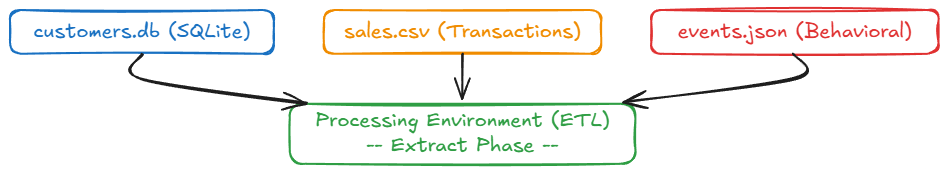

# Extraction phase - I


In [46]:
def extract_sales_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path) 
    logging.info("Extracted sales : %s rows , %s cols", *df.shape)
    return df 

def extarct_events_json(path : Path) -> pd.DataFrame:
    data = json.loads(path.read_text(encoding="utf-8"))
    df = pd.DataFrame(data)
    logging.info("Extracted events : %s rows , %s cols", *df.shape)
    return df 

def extract_customers_sqlite(path: Path) -> pd.DataFrame:
    conn = sqlite3.connect(path) 
    df = pd.read_sql("SELECT * FROM customers", conn) 
    conn.close() 
    logging.info("Extracted customers SQLITE : %s rows , %s cols", *df.shape) 
    return df

sales = extract_sales_csv(DATA_DIR / "sales.csv") 
events = extarct_events_json(DATA_DIR / "events.json") 
customers = extract_customers_sqlite(DATA_DIR / "customers.db")

2026-03-04 03:50:33,909 - INFO - Extracted sales : 2114 rows , 4 cols
2026-03-04 03:50:33,922 - INFO - Extracted events : 1431 rows , 4 cols
2026-03-04 03:50:33,928 - INFO - Extracted customers SQLITE : 400 rows , 4 cols


In [47]:
sales.head()

,sale_id,customer_id,amount,ts
0,1129,1206,104.115737,2023-09-04T00:00:00
1,66,1011,75.543343,2023-09-07T00:00:00
2,951,1169,250.246889,2023-09-12T00:00:00
3,252,1043,355.272957,2023-09-13T00:00:00
4,1658,1313,237.198737,2023-09-14T00:00:00


In [48]:
events.head()

,event_id,customer_id,event_type,ts
0,1,1001,cart_add,2024-05-18T00:00:00
1,2,1001,login,2023-12-26T00:00:00
2,3,1001,view,2024-03-16T00:00:00
3,4,1001,cart_add,2024-05-10T00:00:00
4,5,1001,cart_add,2024-02-02T00:00:00


In [49]:
customers.head() 

,customer_id,country,city,signup_date
0,1001,IN,Delhi,2023-11-22
1,1002,UK,London,2024-03-27
2,1003,US,NYC,2024-02-08
3,1004,IN,Delhi,2024-01-10
4,1005,SG,Singapore,2023-10-05


# Data Validation v

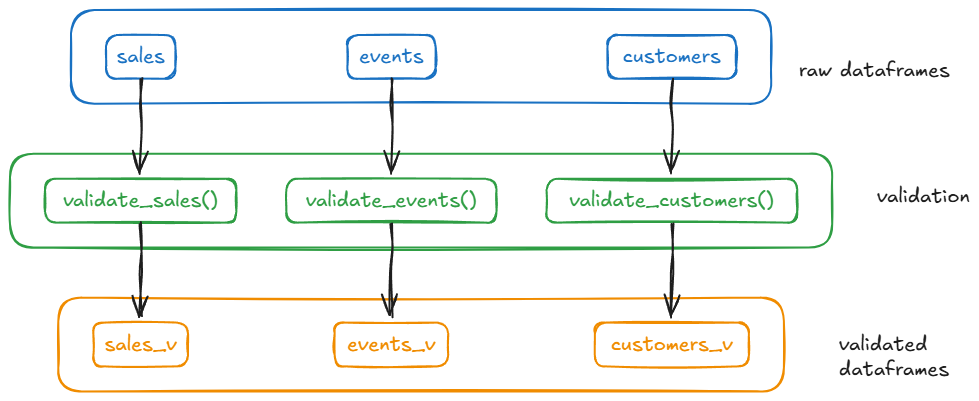

# 1- Sales Validation 





In [50]:
def val_sales(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy() 
    # Check for required columns if not found raise error
    for c in ["sale_id" , "customer_id" , "amount" , "ts"]:
        if c not in df.columns:
            raise ValueError(f"Missing column {c}")
    
    # convert to correct types
    # sales_id , customer_id --> int
    # amount --> float 
    # ts --> datetime 
    df["sale_id"] = pd.to_numeric(df["sale_id"] , errors="coerce").astype("Int64")
    df["customer_id"] = pd.to_numeric(df["customer_id"] , errors="coerce").astype("Int64")
    df["amount"] = pd.to_numeric(df["amount"] , errors="coerce")
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")

    # check the length of the df before precessing
    before = len(df)
    # print(f"Before processing : {before} rows") 

    # 1-Drop rows with missing values
    df = df.dropna(
        subset=["sale_id" , "customer_id" , "amount" , "ts"]
    ).reset_index(drop=True) 

    # 2-turn negative amounts to NaN in the amount column 
    df.loc[df["amount"]<=0 , "amount"] = np.nan 
    # take 5th quantile and multiply by 5 and set to cap
    cap = df["amount"].quantile(0.95) * 5 if df["amount"].notna().sum() > 0 else np.nan 
    # apply the cap
    df.loc[df["amount"]>cap ,"amount"] = cap

    # FILL amounts : customers median --> global median
    df["amount"] = df.groupby("customer_id")["amount"].transform(
        lambda s: s.fillna(s.median())
    )
    # apply the same to the global median to the remaining amounts col
    df["amount"] = df["amount"].fillna(df["amount"].median()) 

    # duplicate by latest ts per sale_id
    df = df.sort_values(
        ["sale_id","ts"]
                        ).drop_duplicates(
                        subset=["sale_id"] , keep="last"
                        )  
    after = len(df) 
    logging.info("Dropped %s rows", before - after)
    logging.info("Validated sales")
    return df

sales_val = val_sales(sales) 


2026-03-04 03:50:40,998 - INFO - Dropped 33 rows
2026-03-04 03:50:40,999 - INFO - Validated sales


# 2- Event Validation

In [53]:

def val_events(df: pd.DataFrame) -> pd.DataFrame:

    req = {"event_id" , "customer_id" , "event_type" , "ts"} 
    if not req.issubset(df.columns):
        raise ValueError(f"Missing columns")  

    df = df.copy() 

    # convert to correct types
    # event_id , customer_id --> int
    # event_type --> string 
    # ts --> datetime 
    df["event_id"] = pd.to_numeric(df["event_id"] , errors="coerce").astype("Int64")
    df["customer_id"] = pd.to_numeric(df["customer_id"] , errors="coerce").astype("Int64")
    df["event_type"] = df["event_type"].astype("string")
    df["ts"] = pd.to_datetime(df["ts"] , errors="coerce") 

    # check the length of the df before precessing
    before = len(df)
    # print(f"Before processing : {before} rows") 

    # 1-Drop rows with missing values
    df = df.dropna(
        subset=["event_id" , "customer_id" , "event_type" , "ts"]
    ).reset_index(drop=True) 

    # duplicate by latest ts per event_id
    df = df.sort_values(
        ["event_id","ts"]
                        ).drop_duplicates(
                        subset=["event_id"] , keep="last"
                        )  
    after = len(df) 
    logging.info("Dropped %s rows", before - after)
    logging.info("Validated events")
    return df


events_val = val_events(events)

2026-03-04 03:52:53,854 - INFO - Dropped 0 rows
2026-03-04 03:52:53,855 - INFO - Validated events


# 3- Customer Validation

In [54]:
def val_customers(df: pd.DataFrame) -> pd.DataFrame:
    req = {"customer_id" , "country" , "city" , "signup_date"} 
    if not req.issubset(df.columns): 
        raise ValueError(f"Missing columns") 

    df = df.copy() 

    # convert to correct types
    # customer_id --> int
    # country --> string 
    # city --> string 
    # signup_date --> datetime 
    df["customer_id"] = pd.to_numeric(df["customer_id"] , errors="coerce").astype("Int64")
    df["country"] = df["country"].astype("string")
    df["city"] = df["city"].astype("string")
    df["signup_date"] = pd.to_datetime(df["signup_date"] , errors="coerce").dt.date

    # check the length of the df before precessing
    before = len(df)
    # print(f"Before processing : {before} rows") 

    # 1-Drop rows with missing values
    df = df.dropna(
        subset=["customer_id" , "country" , "city" , "signup_date"]
    ).reset_index(drop=True) 

    after = len(df) 
    logging.info("Dropped %s rows", before - after)
    logging.info("Validated customers")
    return df 


customers_val = val_customers(customers)
    

2026-03-04 03:57:33,363 - INFO - Dropped 0 rows
2026-03-04 03:57:33,364 - INFO - Validated customers


# NOTE :
The difference you see in your three functions is intentional based on whether the developer wanted to copy before or after early checks. It’s not a functional bug, just a style choice.

Note that the first function is more complex since the data types required more validation and transformation.

Transform phase - I 

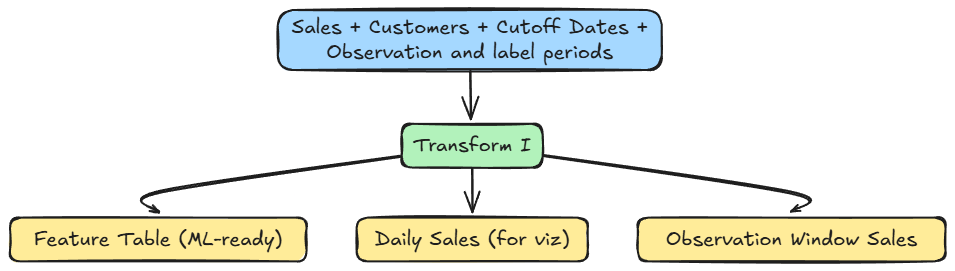

In [ ]:
def transform_make_features(sales: pd.DataFrame, customers: pd.DataFrame,
                            cutoff: pd.Timestamp, obs_days: int,
                            label_days: int):
    # definsive copy
    sales = sales.copy()
    customers = customers.copy()

    # compute time bound (for time series)
    obs_start = cutoff - timedelta(days=obs_days) # START of the observed window
    label_end = cutoff + timedelta(days=label_days) # END of label window

    sales["ts"] = pd.to_datetime(sales["ts"])
    obs_mask = (sales["ts"] >= obs_start) & (sales["ts"] < cutoff)
    label_mask = (sales["ts"] >= cutoff) & (sales["ts"] < label_end)

    sales_obs = sales.loc[obs_mask].copy()
    sales_label = sales.loc[label_mask].copy()

    # Daily time series for viz
    daily_obs = (sales_obs.assign(day=sales_obs["ts"].dt.date)
                 .groupby("day", as_index=False)["amount"].sum()
                 .rename(columns={"amount": "daily_sales"}))

    # RFM-like features
    last_ts = sales_obs.groupby("customer_id")["ts"].max()\
                        .to_frame("last_ts").reset_index()
    last_ts["recency_days"] = (cutoff - last_ts["last_ts"]).dt.days

    agg = sales_obs.groupby("customer_id").agg(
        freq=("sale_id", "count"),
        monetary=("amount", "sum"),
        avg_amount=("amount", "mean"),
        max_amount=("amount", "max")
    ).reset_index()

    def avg_gap(group):
        g = group.sort_values("ts")["ts"].values
        if len(g) < 2:
            return np.nan
        diffs = np.diff(g).astype("timedelta64[D]").astype(float)
        return float(np.mean(diffs))

    gaps = sales_obs.groupby("customer_id",
                            group_keys=False
                            ).apply(avg_gap,
                            include_groups=False).to_frame("avg_gap_days")\
                            .reset_index()

    feats = customers[
                ["customer_id", "country", "city", "signup_date"]
                ].merge(agg, on="customer_id", how="left")
    feats = feats.merge(
                last_ts[["customer_id", "recency_days"]],
                on="customer_id", how="left")
    feats = feats.merge(gaps, on="customer_id", how="left")

    feats["freq"] = feats["freq"].fillna(0).astype(int)
    for c in ["monetary", "avg_amount", "max_amount", "recency_days", "avg_gap_days"]:
        feats[c] = feats[c].astype(float)

    feats["tenure_days"] = (pd.to_datetime(cutoff.date()) \
                        - pd.to_datetime(feats["signup_date"])).dt.days.clip(lower=0)

    has_future_purchase = sales_label.groupby("customer_id")["sale_id"]\
                            .count().reindex(feats["customer_id"]).fillna(0)
    feats["label_churn"] = (has_future_purchase.values == 0).astype(int)

    feats = feats[[
        "customer_id", "country", "city", "tenure_days",
        "freq", "monetary", "avg_amount", "max_amount",
        "recency_days", "avg_gap_days", "label_churn"
    ]]

    return feats, daily_obs, sales_obs

# Choose a sensible default cutoff (75th percentile of observed timestamps)
default_cutoff = pd.to_datetime(sales_val["ts"].quantile(0.75)).normalize()
obs_days, label_days = 200, 60

feats, daily_obs, sales_obs = transform_make_features(
    sales=sales_val, customers=customers_val,
    cutoff=default_cutoff, obs_days=obs_days, label_days=label_days
)

In [57]:
feats.head()

,customer_id,country,city,tenure_days,freq,monetary,avg_amount,max_amount,recency_days,avg_gap_days,label_churn
0,1001,IN,Delhi,217,4,747.345631,186.836408,305.806868,10.0,60.666667,0
1,1002,UK,London,91,3,543.996223,181.332074,296.667684,24.0,9.500000,1
2,1003,US,NYC,139,2,720.305224,360.152612,540.183812,45.0,83.000000,0
3,1004,IN,Delhi,168,2,551.118504,275.559252,457.465972,49.0,37.000000,0
4,1005,SG,Singapore,265,6,1345.933110,224.322185,376.439639,94.0,15.400000,0


In [58]:
daily_obs.head()

,day,daily_sales
0,2023-12-09,353.603166
1,2023-12-10,721.015225
2,2023-12-11,340.068336
3,2023-12-12,438.615601
4,2023-12-13,531.638188


In [59]:
sales_obs.head()

,sale_id,customer_id,amount,ts
876,2,1001,102.734007,2024-03-28
266,3,1001,305.806868,2023-12-17
1491,4,1001,72.385335,2024-06-16
813,5,1001,266.419422,2024-03-20
1226,6,1002,135.879107,2024-05-14


# Load phase - I

In [61]:
def dump_outputs(feats: pd.DataFrame, sales_obs: pd.DataFrame,
                 daily_obs: pd.DataFrame, cutoff: pd.Timestamp,
                 obs_days: int, label_days: int):
    feats.to_csv(OUT_DIR / "features.csv", index=False)
    feats.to_parquet(OUT_DIR / "features.parquet", index=False)
    feats.to_json(OUT_DIR / "features.json",
                    orient="records", indent=2)

    sales_obs.to_csv(OUT_DIR / "sales_observation.csv",
                    index=False)
    sales_obs.to_parquet(OUT_DIR / "sales_observation.parquet",
                        index=False)
    sales_obs.to_json(OUT_DIR / "sales_observation.json",
                    orient="records", indent=2)

    daily_obs.to_csv(OUT_DIR / "daily_sales.csv", index=False)

    data_dict = {
        "features": {
            "customer_id": "Unique customer key",
            "country": "Country code",
            "city": "City name",
            "tenure_days": "Days since signup until cutoff",
            "freq": "Purchase count in observation window",
            "monetary": "Total spend in observation window",
            "avg_amount": "Average spend per purchase (obs window)",
            "max_amount": "Max spend in observation window",
            "recency_days": "Days since last purchase at cutoff",
            "avg_gap_days": "Avg days between purchases (obs window)",
            "label_churn": "1 if NO purchase in label window; else 0"
        }
    }
    save_json(data_dict, OUT_DIR / "data_dictionary.json")
    meta = {
        "run_timestamp": datetime.now().isoformat(timespec="seconds"),
        "rng_seed": RNG_SEED,
        "params": {
            "cutoff": str(cutoff.date()),
            "obs_days": obs_days,
            "label_days": label_days
        },
        "rows": {
            "features": int(len(feats)),
            "sales_obs": int(len(sales_obs)),
            "daily_obs": int(len(daily_obs))
        }
    }
    save_json(meta, OUT_DIR / "run_metadata.json")

    qa = {
        "n_customers_total": int(
                            customers_v["customer_id"].nunique()),
        "n_customers_with_obs_purchases": int(
                                sales_obs["customer_id"].nunique()),
        "n_features_rows": int(len(feats)),
        "churn_rate": float(feats["label_churn"].mean()),
        "obs_window_start": str(
                        (cutoff - timedelta(days=obs_days)).date()),
        "cutoff": str(cutoff.date()),
        "label_window_end": str(
                        (cutoff + timedelta(days=label_days)).date())
    }
    save_json(qa, OUT_DIR / "qa_report.json")
    return qa

qa = dump_outputs(
                feats, sales_obs, daily_obs, 
                default_cutoff, obs_days, label_days
                )

/tmp/ipykernel_2145274/4037490449.py:13: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  sales_obs.to_json(OUT_DIR / "sales_observation.json",


NameError: name 'RNG_SEED' is not defined